In [ ]:
# Local interpretation: explain prediction on sample 5 using MLP SHAP values
shap.plots.waterfall(shap.Explanation(
    values=shap_values[5, :, 1],
    base_values=explainer.expected_value[1],
    data=X_scaled.iloc[5],
    feature_names=X_scaled.columns.tolist()
))

# C) Local interpretation on MLP using SHAP waterfall

# AI Interpretation Tools

# importing data

In [22]:
#importing data
import numpy as np 
import pandas as pd 

df = pd.read_csv('./heart_failure_clinical_records_dataset.csv') #make sure to replace with your data directory
df.drop(columns=['time'],inplace=True) #drop the time column which is not one of the informative features 
df_features = df.iloc[:,:-1]
df_target = df['DEATH_EVENT']

X = df_features
y = df_target

# Create train and test splits

In [23]:
#Create train and test splits
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3,stratify=y,random_state=42)

# Normalization step

In [24]:
#Normalizing data for prediction step 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
#Normalize whole data for interpretation step 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to pandas DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
X_scaled

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking
0,1.192945,-0.871105,0.000166,-0.847579,-1.530560,1.359272,1.681648e-02,0.490057,-1.504036,0.735688,-0.687682
1,-0.491279,-0.871105,7.514640,-0.847579,-0.007077,-0.735688,7.535660e-09,-0.284552,-0.141976,0.735688,-0.687682
2,0.350833,-0.871105,-0.449939,-0.847579,-1.530560,-0.735688,-1.038073e+00,-0.090900,-1.731046,0.735688,1.454161
3,-0.912335,1.147968,-0.486071,-0.847579,-1.530560,-0.735688,-5.464741e-01,0.490057,0.085034,0.735688,-0.687682
4,0.350833,1.147968,-0.435486,1.179830,-1.530560,-0.735688,6.517986e-01,1.264666,-4.682176,-1.359272,-0.687682
...,...,...,...,...,...,...,...,...,...,...,...
294,0.098199,-0.871105,-0.537688,1.179830,-0.007077,1.359272,-1.109765e+00,-0.284552,1.447094,0.735688,1.454161
295,-0.491279,-0.871105,1.278215,-0.847579,-0.007077,-0.735688,6.802472e-02,-0.187726,0.539054,-1.359272,-0.687682
296,-1.333392,-0.871105,1.525979,1.179830,1.854958,-0.735688,4.902082e+00,-0.575031,0.312044,-1.359272,-0.687682
297,-1.333392,-0.871105,1.890398,-0.847579,-0.007077,-0.735688,-1.263389e+00,0.005926,0.766064,0.735688,1.454161


# Partial Least Square Discriminant Analysis (PLS-DA)

In [26]:
#PLSDA model
from sklearn.cross_decomposition import PLSRegression

# Create PLS model with 2 components
pls = PLSRegression(n_components=2)

# Fit on training data
pls.fit(X_train, y_train)

# Predict on test data (returns continuous values)
y_pred_continuous = pls.predict(X_test)

# Convert to binary (PLS-DA step)
y_pred = (y_pred_continuous >= 0.5).astype(int).ravel()

In [27]:
y_pred

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0])

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.7222222222222222
Precision: 0.625
Recall: 0.3448275862068966
F1-score: 0.4444444444444444


# 1- Interpretation step on PLS-DA

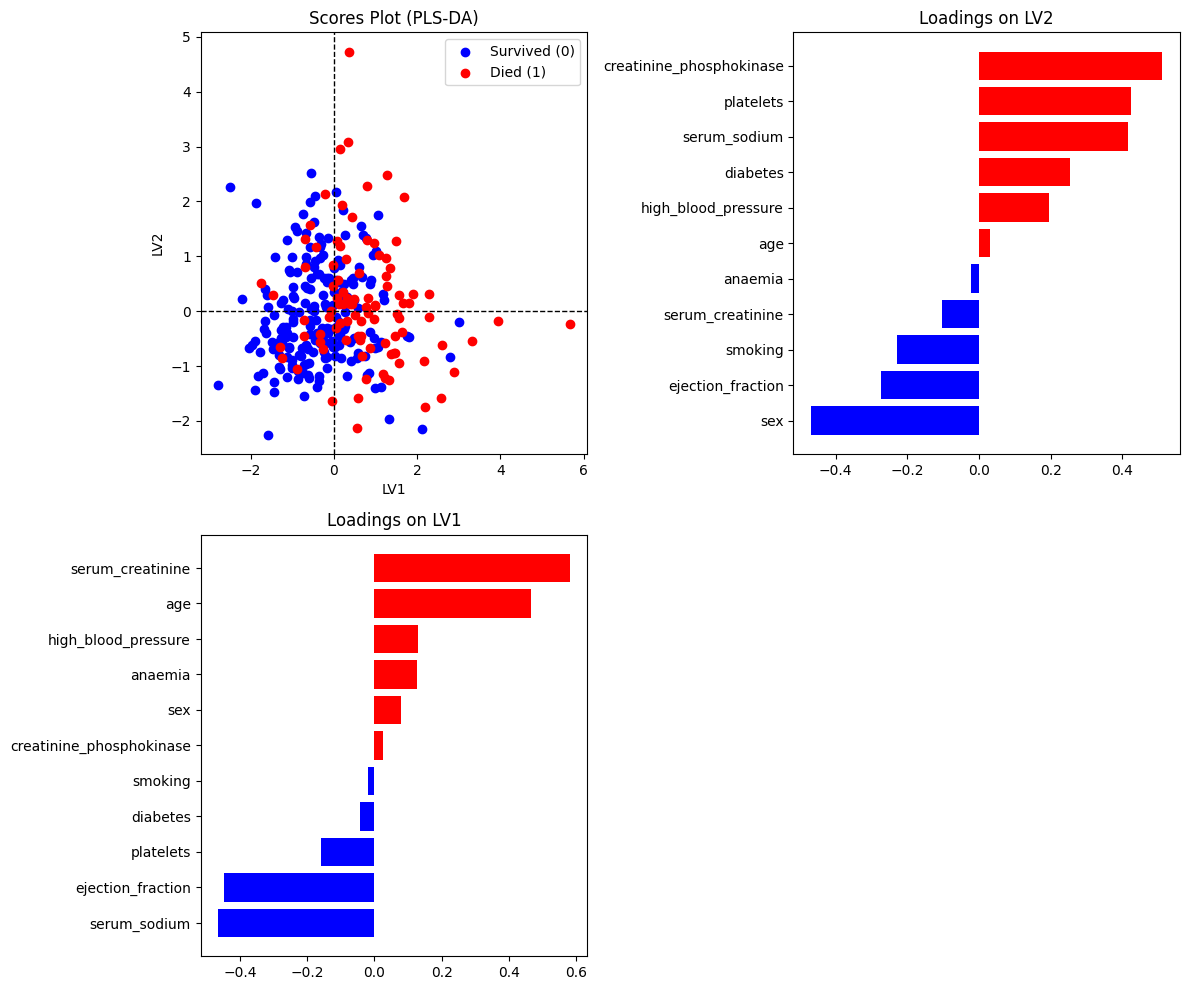

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression

# Fit PLS-DA on full dataset
pls = PLSRegression(n_components=2)
pls.fit(X_scaled, y)

# Scores and loadings
scores = pls.x_scores_
loadings = pls.x_loadings_

scores_df = pd.DataFrame(scores, columns=['LV1', 'LV2'])
loadings_df = pd.DataFrame(loadings, index=X_scaled.columns, columns=['LV1', 'LV2'])

# ---- Plotting ----
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ---- (1,1) Scores plot ----
ax = axes[0, 0]

# Plot each class separately for legend
mask_0 = (y == 0)
mask_1 = (y == 1)

ax.scatter(scores_df.loc[mask_0, 'LV1'], scores_df.loc[mask_0, 'LV2'],
           color='blue', label='Survived (0)')
ax.scatter(scores_df.loc[mask_1, 'LV1'], scores_df.loc[mask_1, 'LV2'],
           color='red', label='Died (1)')

# Add dashed reference lines
ax.axhline(0, linestyle='--', linewidth=1, color='black')
ax.axvline(0, linestyle='--', linewidth=1, color = 'black')

ax.set_title('Scores Plot (PLS-DA)')
ax.set_xlabel('LV1')
ax.set_ylabel('LV2')
ax.legend()

# ---- (2,1) Loadings LV1 ----
ax = axes[1, 0]
lv1_sorted = loadings_df['LV1'].sort_values()
colors_lv1 = ['blue' if val < 0 else 'red' for val in lv1_sorted]

ax.barh(lv1_sorted.index, lv1_sorted.values, color=colors_lv1)
ax.set_title('Loadings on LV1')

# ---- (1,2) Loadings LV2 ----
ax = axes[0, 1]
lv2_sorted = loadings_df['LV2'].sort_values()
colors_lv2 = ['blue' if val < 0 else 'red' for val in lv2_sorted]

ax.barh(lv2_sorted.index, lv2_sorted.values, color=colors_lv2)
ax.set_title('Loadings on LV2')

# ---- (2,2) Empty ----
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Excercise: Plot the scores and loadings for LV2 and LV3


In [30]:
#Write your code here

# 2- Interpretation with SHAP

First step is to design a classifier and use SHAP to explain this classification for you

# A) Global Interpretation: Shap beeswarm plot or summary plot

(299, 11, 2)


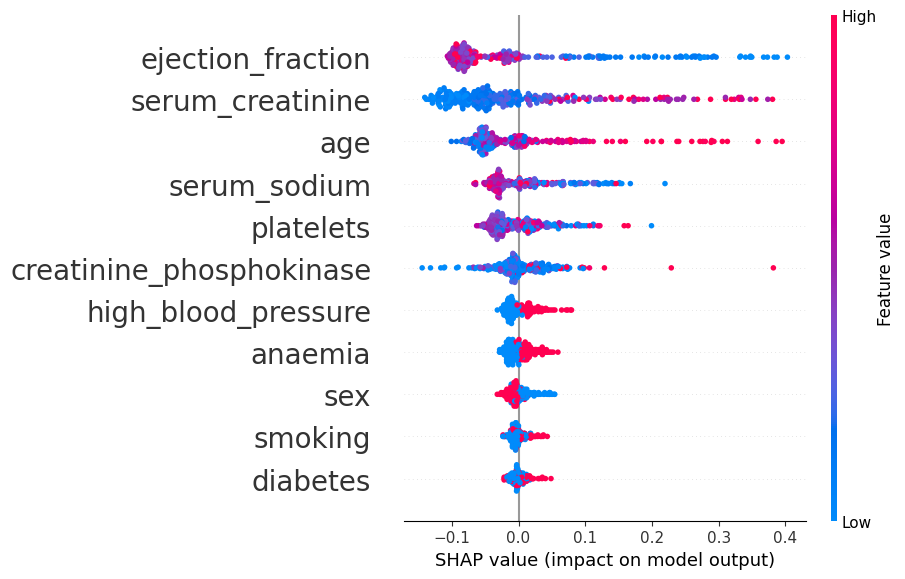

In [31]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Fit on full scaled dataset
rf.fit(X_scaled, y)

import shap
# Create SHAP explainer
explainer = shap.Explainer(rf, X_scaled)
shap_values = explainer(X_scaled)
print(shap_values.shape)
fig = shap.summary_plot(shap_values[:,:,1],X_scaled,show=False)
# Get the current axes and change the font size of y-axis (feature names)
plt.gca().tick_params(axis='y', labelsize=20)  
plt.show()


# B) Local interpretation on a single sample use SHAP waterfall plot

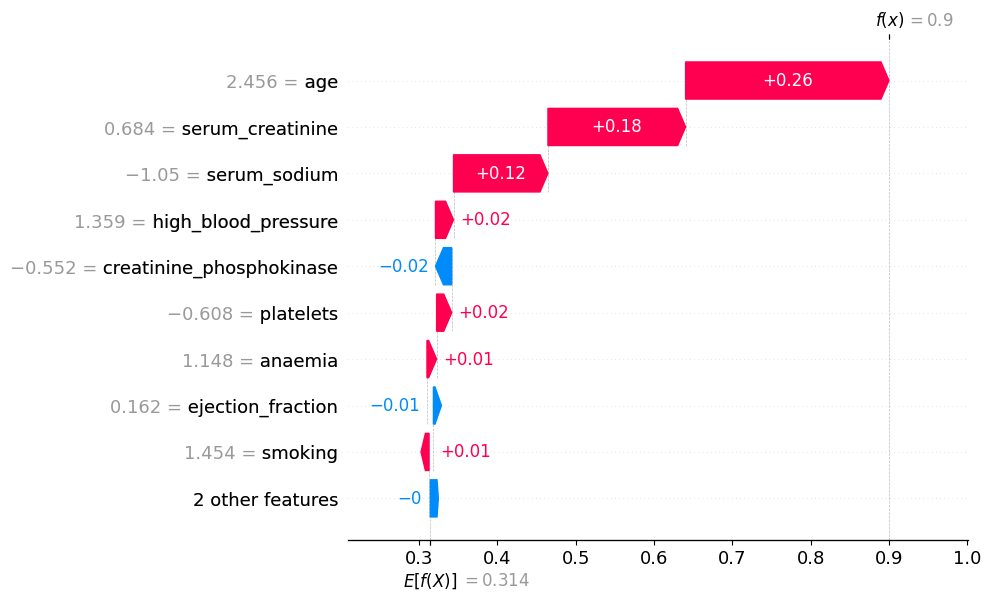

In [32]:
#here we explain the prediction on sample number 5 (row 5) 
idx = 5
shap.plots.waterfall(shap_values[5,:,1])

# Use SHAP on  a deep learning model (a simple MLP model)

A simple MLP model with 1 hidden layer, 10 neurons, ReLU activation, Binary cross entropy loss, Adam optimizer, and 200 epochs

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convert data to torch tensors
X_tensor = torch.tensor(X_scaled.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).view(-1, 1)

# Define simple MLP (1 hidden layer)
class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super(SimpleMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Linear(10, 1),
            nn.Sigmoid()  # output probability
        )

    def forward(self, x):
        return self.net(x)

# Initialize model
model = SimpleMLP(input_dim=X_tensor.shape[1])

# Loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
for epoch in range(200):
    model.train()
    
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


def model_predict(x_numpy):
    model.eval()
    x_tensor = torch.tensor(x_numpy, dtype=torch.float32)
    with torch.no_grad():
        preds = model(x_tensor).numpy()
    return np.hstack([1 - preds, preds])  # [P(class 0), P(class 1)]

ModuleNotFoundError: No module named 'torch'

In [ ]:
model

SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

100%|██████████| 299/299 [00:10<00:00, 29.67it/s]


(299, 11, 2)


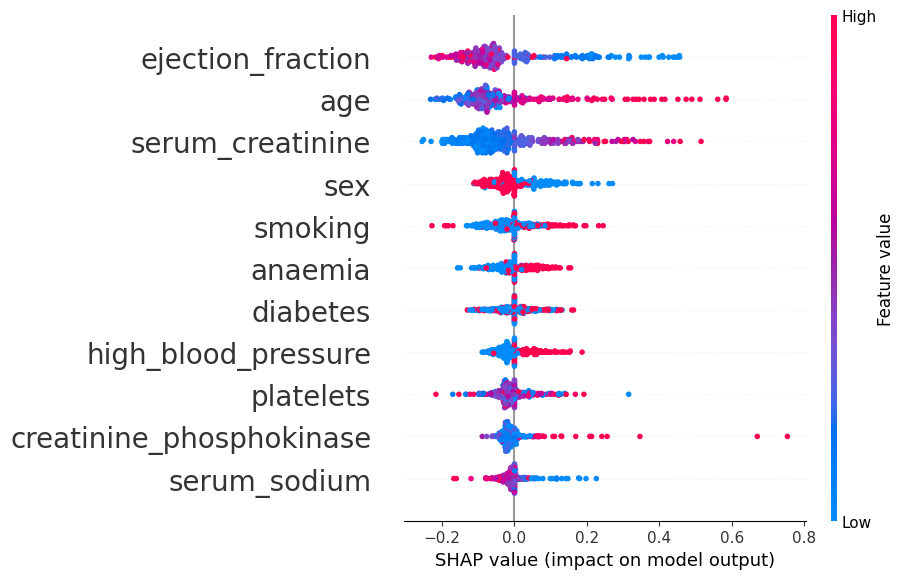

In [ ]:
import shap
import numpy as np

# Background sample (important for speed)
background = shap.sample(X_scaled, 100, random_state=42)

# Kernel SHAP
explainer = shap.KernelExplainer(model_predict, background)

# Compute SHAP values
shap_values = explainer.shap_values(X_scaled)

# Beeswarm plot for class 1 (death)
#shap.summary_plot(shap_values[:,:,1], X_scaled)

print(shap_values.shape)

fig = shap.summary_plot(shap_values[:,:,1],X_scaled,show=False)
# Get the current axes and change the font size of y-axis (feature names)
plt.gca().tick_params(axis='y', labelsize=20)  
plt.show()